# Gradient Descent

> "Gradient Descent is a first-order iterative optimization algorithm used for finding the local minimum of a differentiable function. The idea is to take repetitive steps in the opposite direction of the gradient of the function at the current point, since this is the direction of steepest descent."

It is used in:

- Deep Learning
- Linear Regression
- Logistic Regression

---

Since calculating matrix inverse is computationally expensive in the Least Squares method, we prefer Gradient Descent for high-dimensional data.

---

# Intuition

Our goal is to minimize the loss function.

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Substituting:

$$
L = \sum_{i=1}^{n} (y_i - mx_i - b)^2
$$

We need to adjust \(m\) and \(b\) to minimize the loss function:

$$
L(m,b)
$$

---

Suppose slope \(m\) is constant.

Then the loss becomes only a function of \(b\):

$$
L(b)
$$

Plotting the graph:

![](./images/img4.png)

---

We start from a random value of \(b\) and iteratively try to reach the minimum point where loss is minimum.

At the current value of \(b\), we calculate the derivative (slope) of the loss function.

- If slope is positive → decrease \(b\)
- If slope is negative → increase \(b\)

So the update rule becomes:

$$
b_{\text{new}} = b_{\text{old}} - \frac{dL}{db}
$$

This repeatedly moves us toward the minimum loss.


We add a **learning rate** because using only the slope value can make the updates too large, causing the function to overshoot the minimum point and oscillate in a zig-zag manner instead of converging smoothly.

So the final update equation becomes:

$$
b_{\text{new}} = b_{\text{old}} - \eta \frac{dL}{db}
$$

Where:

- \(\eta\) = learning rate  
- \(\frac{dL}{db}\) = slope (gradient) of the loss function


## Stopping Condition

We stop the iterations when the parameter updates become very small:

$$
|b_{\text{new}} - b_{\text{old}}| < 0.0001
$$

This indicates that the algorithm is converging toward the minimum solution.

---

The number of complete iterations is called an **epoch**.

## Maths Formula

We know the loss function is:

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Substituting:

$$
L = \sum_{i=1}^{n} (y_i - mx_i - b)^2
$$

To update \(b\), we calculate the derivative of the loss function w.r.t. \(b\):

$$
\frac{dL}{db}
=
\frac{d}{db}
\left(
\sum_{i=1}^{n} (y_i - mx_i - b)^2
\right)
$$

Applying chain rule:

$$
\frac{dL}{db}
=
2 \sum_{i=1}^{n} (y_i - mx_i - b)(-1)
$$

So:

$$
\frac{dL}{db}
=
-2 \sum_{i=1}^{n} (y_i - mx_i - b)
$$

This is the slope equation used in the update rule.

---

## Update Equation

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta \times \text{slope}
$$

Substituting the slope:

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta
\left(
-2 \sum_{i=1}^{n} (y_i - mx_i - b)
\right)
$$

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

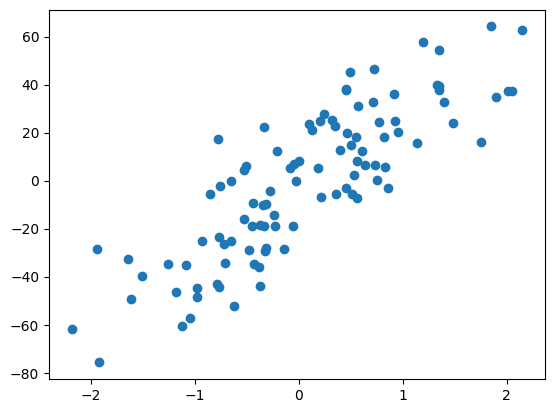

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)
print(lr.coef_)         
print(lr.intercept_)   

[28.12597332]
-2.2710144261783825


In [8]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [15]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b

In [16]:
gd = GDRegressor(0.001 , 50)

In [17]:
gd.fit(X_train, y_train)

28.159367347119066 -2.3004574196824854


In [18]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579

In the class you might have noticed that we also consider **m as a variable**, which is practically true.

So we need to apply **gradient descent for two variables**.

We initialize random values for \(m\) and \(b\).  
We also decide the number of epochs and the learning rate.

---

## Update Rules

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta \times \text{slope}
$$

$$
m_{\text{new}}
=
m_{\text{old}}
-
\eta \times \text{slope}
$$

---

Here, the slope is replaced by **partial derivatives**.

## Partial Derivatives

For \(b\):

$$
\frac{\partial L}{\partial b}
=
-2 \sum_{i=1}^{n} (y_i - mx_i - b)
$$

For \(m\):

$$
\frac{\partial L}{\partial m}
=
-2 \sum_{i=1}^{n} x_i (y_i - mx_i - b)
$$

---

## Final Update Equations

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta \frac{\partial L}{\partial b}
$$

$$
m_{\text{new}}
=
m_{\text{old}}
-
\eta \frac{\partial L}{\partial m}
$$

# Types of Gradient Descent

## 1. Batch Gradient Descent (Batch GD)

This is the method we have discussed till now.

- The entire dataset is used to calculate gradients
- Parameters are updated after processing all rows

### Advantage:
- Stable convergence

### Disadvantage:
- Slow for very large datasets

---

## 2. Stochastic Gradient Descent (SGD)

Here, we use only one row at a time to calculate the gradient and update parameters.

- One training example → one update

### Advantage:
- Faster updates
- Works well for very large datasets

### Disadvantage:
- Updates are noisy and less stable

---

## 3. Mini Batch Gradient Descent

Here, we divide the dataset into small batches.

- Parameters are updated after processing each batch

It lies between Batch GD and SGD.

### Advantage:
- Faster than Batch GD
- More stable than SGD

Mini-batch gradient descent is the most commonly used approach in deep learning.

# Batch Gradient Descent

We previously discussed gradient descent for **Simple Linear Regression** (single input and single output).

Now let us discuss **Multiple Linear Regression**, where we need to find multiple parameters:

$$
\beta_0, \beta_1, \beta_2, \dots, \beta_n
$$

for \(n\)-dimensional data.

---

Suppose we only have:

$$
\beta_0, \beta_1, \beta_2
$$

---

## Step 1: Initialize Random Values

Example:

$$
\beta_0 = 0
$$

$$
\beta_1 = 1
$$

$$
\beta_2 = 1
$$

---

## Step 2: Choose Hyperparameters

Example:

- Epochs = 100
- Learning Rate = 0.1

---

## Step 3: Update Equations

$$
\beta_{0,\text{new}}
=
\beta_{0,\text{old}}
-
\eta
\frac{\partial L}{\partial \beta_0}
$$

$$
\beta_{1,\text{new}}
=
\beta_{1,\text{old}}
-
\eta
\frac{\partial L}{\partial \beta_1}
$$

$$
\beta_{2,\text{new}}
=
\beta_{2,\text{old}}
-
\eta
\frac{\partial L}{\partial \beta_2}
$$

---

Now the loss function depends on all parameters:

$$
L(\beta_0, \beta_1, \beta_2)
$$

So the slopes are partial derivatives.

---

## Partial Derivatives

For bias term:

$$
\frac{\partial L}{\partial \beta_0}
=
-2 \sum_{i=1}^{n}
(y_i - \hat{y}_i)
$$

For first feature:

$$
\frac{\partial L}{\partial \beta_1}
=
-2 \sum_{i=1}^{n}
x_{i1}(y_i - \hat{y}_i)
$$

For second feature:

$$
\frac{\partial L}{\partial \beta_2}
=
-2 \sum_{i=1}^{n}
x_{i2}(y_i - \hat{y}_i)
$$

---

These updates are repeated for every epoch until the loss converges.

In [19]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [20]:
X,y = load_diabetes(return_X_y=True)

In [21]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [24]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [26]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [27]:
X_train.shape

(353, 10)

In [29]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [30]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)

In [31]:
gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [32]:
y_pred = gdr.predict(X_test)

In [33]:
r2_score(y_test,y_pred)

0.4534503034722803

# Stochastic Gradient Descent (SGD)

Batch Gradient Descent becomes slow for very large datasets because it uses the entire dataset before updating parameters.

In Stochastic Gradient Descent (SGD):

- We select only one training example at a time
- The row is selected randomly (not always the first row)
- Parameters are updated immediately after processing that single row

---

## Steps

1. Select one random row from the dataset  
2. Calculate prediction and loss for that row  
3. Compute gradients  
4. Update parameters  
5. Repeat for another random row  

---

## Advantage

- Much faster for large datasets
- Requires less memory

---

## Disadvantage

- Updates are noisy
- Loss function may fluctuate instead of smoothly decreasing

In [34]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [35]:
X,y = load_diabetes(return_X_y=True)

In [36]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [38]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [40]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [41]:
class SGDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                
                intercept_der = -2 * (y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
                
                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [42]:
sgd = SGDRegressor(learning_rate=0.01,epochs=40)

In [43]:
start = time.time()
sgd.fit(X_train,y_train)
print("The time taken is",time.time() - start)

147.59035237596981 [  61.10626426  -44.71927516  317.61041325  224.45534619   28.24764749
   -7.27537127 -162.72116445  133.34567236  284.48148418  126.47629406]
The time taken is 0.34203267097473145


In [44]:
y_pred = sgd.predict(X_test)

In [45]:
r2_score(y_test,y_pred)

0.4169892946059103

In [46]:
from sklearn.linear_model import SGDRegressor

In [47]:
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)

In [48]:
reg.fit(X_train,y_train)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [49]:
y_pred = reg.predict(X_test)

In [50]:
r2_score(y_test,y_pred)

0.43207420688517717

## When to Use Stochastic Gradient Descent (SGD)

SGD is preferred:

- For very large datasets
- For non-convex functions (common in deep learning)

Because parameters are updated frequently, SGD can sometimes escape local minima better than Batch Gradient Descent.

---

## In Scikit-learn

In Scikit-learn, Stochastic Gradient Descent for regression is implemented using:

```python
SGDRegressor

# Mini Batch Gradient Descent

Stochastic Gradient Descent is fast but noisy because updates are random.

Batch Gradient Descent is stable but slow because it processes the entire dataset before updating parameters.

Mini Batch Gradient Descent combines the advantages of both.

---

## Idea

We divide the dataset into small batches.

Instead of:

- using the entire dataset (Batch GD)
- using a single row (SGD)

we use a small group of rows called a **mini batch**.

Parameters are updated after processing each batch.

---

## Advantages

- Faster than Batch Gradient Descent
- More stable than Stochastic Gradient Descent
- Efficient for GPU computation

---

Although named Stochastic, SGDRegressor actually supports mini-batch learning internally.

You control batch-like behavior using partial_fit()

In [51]:

from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [52]:
X,y = load_diabetes(return_X_y=True)

In [53]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [55]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [57]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [58]:
import random

class MBGDRegressor:
    
    def __init__(self,batch_size,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            
            for j in range(int(X_train.shape[0]/self.batch_size)):
                
                idx = random.sample(range(X_train.shape[0]),self.batch_size)
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                #print("Shape of y_hat",y_hat.shape)
                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [59]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50),learning_rate=0.01,epochs=100)

In [60]:
mbr.fit(X_train,y_train)

151.4119610380778 [  29.06683312 -133.07714883  438.25202344  301.83407908  -20.05082344
  -94.0604368  -186.62169742  112.24109957  412.75844288  114.54228978]


In [61]:
y_pred = mbr.predict(X_test)

In [62]:
r2_score(y_test,y_pred)

0.4511501594181295

In [63]:
from sklearn.linear_model import SGDRegressor

In [64]:
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)

In [65]:
batch_size = 35

for i in range(100):
    
    idx = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [66]:
sgd.coef_

array([  43.19877232,  -69.87602028,  331.82665277,  247.49670799,
         14.31937574,  -28.91216618, -172.07067538,  122.50519261,
        312.15652608,  132.84950644])

In [67]:
sgd.intercept_

array([168.31378053])

In [68]:
y_pred = sgd.predict(X_test)

In [69]:
r2_score(y_test,y_pred)

0.38825918547567706